In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

# --- 設定 ---
DATASET_NAME = 'imagenette/320px-v2' 
BATCH_SIZE = 128
IMG_SIZE = 256

# ===================================================
# 步驟 0: GPU 檢查與配置
# ===================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # 設定 GPU 記憶體動態增長
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"成功偵測到 {len(gpus)} 個 GPU，(TF 版本: {tf.__version__})")
    except RuntimeError as e:
        print(f"GPU 設定失敗: {e}")
else:
    print("未偵測到 GPU，訓練將在 CPU 上運行。")

# ===================================================
# 步驟 1: 載入資料集
# ===================================================
print(f"--- 正在載入資料集：{DATASET_NAME} ---")
(ds_train_full, ds_validation_full), ds_info = tfds.load(
    DATASET_NAME,
    split=['train', 'validation'],
    as_supervised=True,
    with_info=True
)

class_names = ds_info.features['label'].names
num_classes = ds_info.features['label'].num_classes

print("資料集已就緒。")
print(f"訓練集數量: {ds_info.splits['train'].num_examples:,} | 驗證集數量: {ds_info.splits['validation'].num_examples:,}")
print(f"分類類別數: {ds_info.features['label'].num_classes}")

成功偵測到 1 個 GPU，(TF 版本: 2.10.0)
--- 正在載入資料集：imagenette/320px-v2 ---
資料集已就緒。
訓練集數量: 9,469 | 驗證集數量: 3,925
分類類別數: 10



--- 正在統計真實類別分布... ---


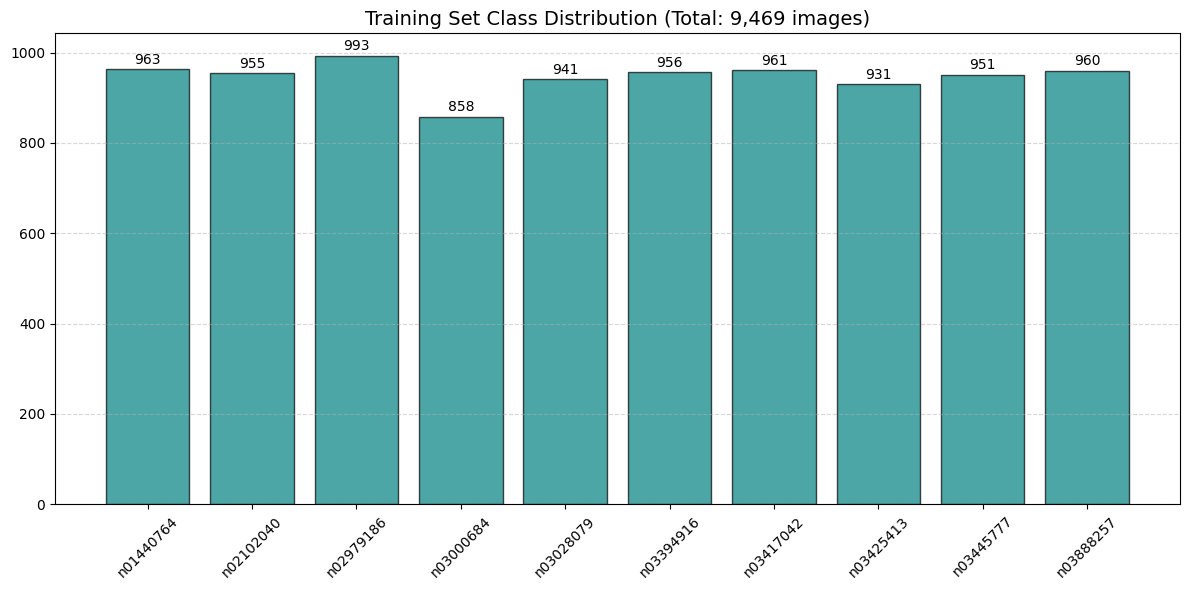


--- 隨機抽取圖片展示 ---


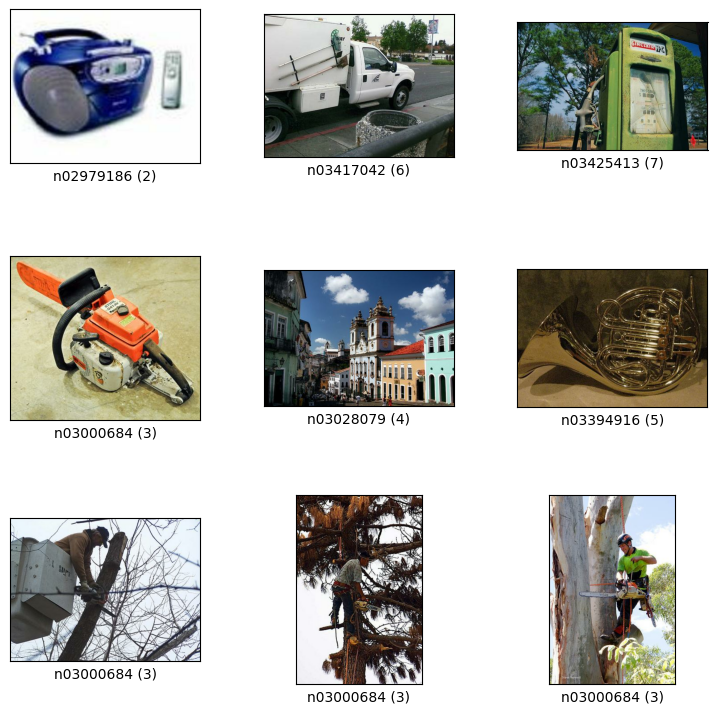


CNN 資料管線已就緒，準備開始訓練畢業專題模型！


In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
# ===================================================
# 步驟 2.1: 快速統計類別分布
# ===================================================
print("\n--- 正在統計真實類別分布... ---")

# 高效提取標籤
labels_only_ds = ds_train_full.map(lambda img, label: label)
all_labels = np.array(list(labels_only_ds.as_numpy_iterator()))
counts = np.bincount(all_labels)

# 繪製長條圖 
plt.figure(figsize=(12, 6))
bars = plt.bar(class_names, counts, color='teal', alpha=0.7, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., yval + 5, f'{int(yval)}', ha='center', va='bottom')

plt.title(f"Training Set Class Distribution (Total: {counts.sum():,} images)", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ===================================================
# 步驟 2.2: 預處理與隨機展示
# ===================================================
def normalize_img(image, label):
    # 調整尺寸
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # 💡 專業建議：自定義 CNN 強烈建議正規化到 [0, 1]，能讓梯度更穩定
    return tf.cast(image, tf.float32) / 255.0, label

def augment(image, label):
    # 增加隨機水平翻轉，增加模型泛化能力
    image = tf.image.random_flip_left_right(image)
    return image, label

print("\n--- 隨機抽取圖片展示 ---")
tfds.show_examples(ds_train_full, ds_info)
plt.show()


# ===================================================
# 步驟 2.3: 準備高效訓練管線 (Pipeline)
# ===================================================
BUFFER_SIZE = tf.data.AUTOTUNE 

ds_train = (ds_train_full
            .map(normalize_img, num_parallel_calls=BUFFER_SIZE)
            .cache() 
            .map(augment, num_parallel_calls=BUFFER_SIZE)
            .shuffle(buffer_size=1000) 
            .batch(BATCH_SIZE)
            .prefetch(BUFFER_SIZE))

ds_validation = (ds_validation_full
                 .map(normalize_img, num_parallel_calls=BUFFER_SIZE)
                 .batch(BATCH_SIZE)
                 .prefetch(BUFFER_SIZE))

print(f"\nCNN 資料管線已就緒，準備開始訓練畢業專題模型！")

3.1:隨機選擇要不要翻轉
因為傳統只會讓機器死背，但這樣會讓LOSS下降很多，所以翻轉圖片，讓機器學習狗的耳朵長什麼樣，鼻子在哪...讓它更加準確

In [3]:
import tensorflow as tf
import time
import numpy as np

# ===================================================
# 0. 環境變數防呆 
# ===================================================
if 'strategy' not in locals():
    strategy = tf.distribute.OneDeviceStrategy(device="/gpu:0")

if 'FullHistoryLogger' not in locals():
    class FullHistoryLogger(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            self.train_start_time = time.time()
            print(f"訓練啟動時間: {time.strftime('%H:%M:%S', time.localtime())}")
            print("=" * 70)
        def on_epoch_begin(self, epoch, logs=None):
            self.epoch_start_time = time.time()
        def on_epoch_end(self, epoch, logs=None):
            duration = time.time() - self.epoch_start_time
            acc, val_acc = logs.get('accuracy', 0), logs.get('val_accuracy', 0)
            print(f"\n[Epoch {epoch + 1}] 結算: 耗時 {duration:.2f}s | Acc: {acc:.4f} | Val_Acc: {val_acc:.4f}")
            print("-" * 70)

# ===================================================
# 3.1 & 3.2 模型定義與編譯
# ===================================================
with strategy.scope(): 
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        
        # 第一層捲積：抓取基礎特徵
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # 第二層捲積：抓取中階特徵
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # 第三層捲積：深度特徵提取
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        # 使用 GlobalAveragePooling 減少參數，防止在小資料集上過擬合
        tf.keras.layers.GlobalAveragePooling2D(), 
        
        # 全連接層進行決策
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2), # 增加魯棒性
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

print("自定義 CNN 模型已就緒，準備開始訓練。")
model.summary()

# ===================================================
# 3.3 訓練模型
# ===================================================
EPOCHS = 15
history_logger = FullHistoryLogger()

print(f"\n--- 開始訓練 (目標: {EPOCHS} 個週期) ---")

history = model.fit(
    ds_train,
    epochs=EPOCHS,
    validation_data=ds_validation,
    verbose=2, 
    callbacks=[history_logger]
)

total_time = (time.time() - history_logger.train_start_time) / 60
print(f"\n訓練完成！總耗時: {total_time:.2f} 分鐘")

自定義 CNN 模型已就緒，準備開始訓練。
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 128, 128, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 64, 64, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 128)       73856     
                                                                 
 global_average_pooling2d (G  (Non


--- 訓練結果分析 ---
最低驗證損失 (Min Validation Loss): 1.4305
模型達到最低驗證損失的 最佳時間 (Best Epoch) 是第 14 週期。


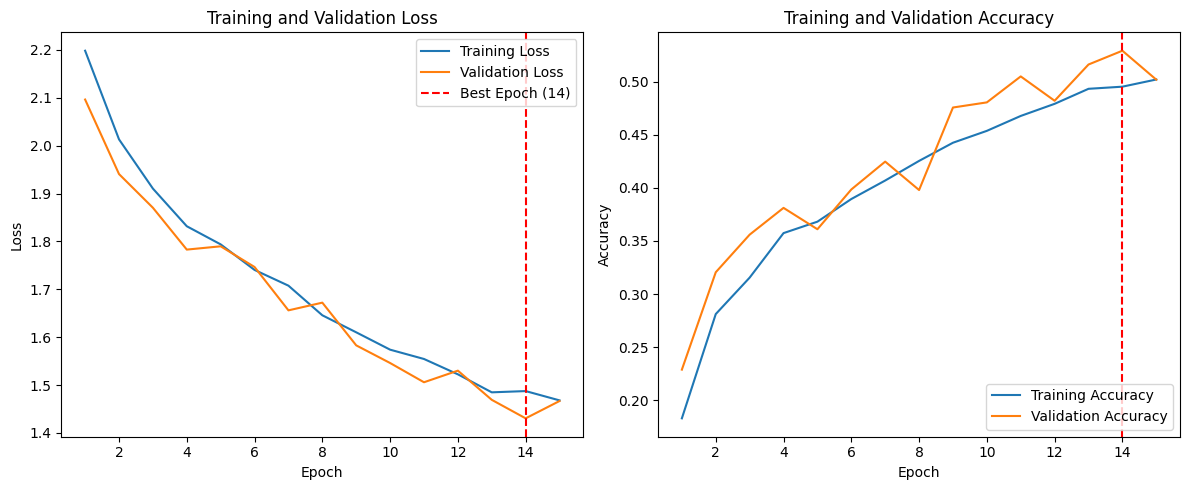

已生成圖表：training_history_imagenette.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ===================================================
# 4.1 找出最佳時間
# ===================================================
val_loss = history.history['val_loss']
min_val_loss = min(val_loss)
best_epoch = np.argmin(val_loss) + 1 # 週期從 1 開始

print(f"\n--- 訓練結果分析 ---")
print(f"最低驗證損失 (Min Validation Loss): {min_val_loss:.4f}")
print(f"模型達到最低驗證損失的 最佳時間 (Best Epoch) 是第 {best_epoch} 週期。")

# ===================================================
# 4.2 繪製 Accuracy 和 Loss 曲線圖
# ===================================================
def plot_history(history, filename='training_history_imagenette.png'):
    """繪製訓練過程中的 Accuracy 和 Loss 曲線圖。"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    #讓 X 軸從 1 開始算 (1 到 epochs)
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # 繪製 Loss 曲線
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    # 微調：X 軸校正後，垂直線直接畫在 best_epoch 即可
    plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    # 繪製 Accuracy 曲線
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=best_epoch, color='r', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_history(history)
print(f"已生成圖表：training_history_imagenette.png")